# G-code expected-print mask from camera/toolhead position

This version selects the print layer by **layer index** instead of by frame/G-code Z. `LAYER_INDEX = 0` is the first/bottom extrusion layer, `1` is the next, etc. This avoids frame-Z calibration mismatch.

For the uploaded one-layer annular disc, use `LAYER_INDEX = 0`.


In [96]:
from pathlib import Path
import re, math
import numpy as np
import cv2
import matplotlib.pyplot as plt

GCODE_PATH = Path('P4_one_layer_annular_disc_60OD_12ID_0p20H.gcode')
FRAME_PATH = Path(r"C:\Users\dhruv\Documents\dhruv_python\disc2accurate\frame_324_t_5887.451996_x_171.014090_y_143.283674_z_0.132901.jpg")
EMPTY_TEMPLATE_PATH = Path(r"C:\Users\dhruv\Documents\dhruv_python\disc2accurate\frame_2419_t_6020.320204_x_193.516000_y_105.383861_z_1.086427.jpg")
FULL_TEMPLATE_PATH = Path(r"C:\Users\dhruv\Documents\dhruv_python\disc2accurate\frame_2405_t_6019.452248_x_180.866510_y_141.850812_z_0.129810.jpg")


# Laser local mask size from make_laser_image.py constants: w=80, l=325
MASK_SHAPE = (80, 315)  # rows/across laser width, cols/along laser length

# Calibration values to tune
PX_PER_MM = 26.13         # replace with your measured pixel/mm value
THETA_DEG =  26.2     # angle of mask columns in printer XY, degrees. 0 => +X
LINE_WIDTH_MM = 0.45
VIEW_CENTER_OFFSET_MM = (0.0, 0.0)  # camera optical/laser mask center relative to reported XY

# Layer selection: 0 is the first/bottom extrusion layer, 1 is the next, etc.
LAYER_INDEX = 0
INCLUDE_PREVIOUS_LAYERS = False  # True => already-printed material up through this layer


In [97]:
WORD_RE = re.compile(r'([A-Za-z])\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)')
XYZ_RE = re.compile(r'(?:^|[_-])x_([-+]?\d*\.?\d+)_y_([-+]?\d*\.?\d+)_z_([-+]?\d*\.?\d+)')

def parse_frame_xyz(path):
    m = XYZ_RE.search(Path(path).stem)
    if not m:
        raise ValueError(f'Could not parse x/y/z from {path}')
    return tuple(map(float, m.groups()))

def parse_gcode_extrusion_segments(path):
    pos = dict(X=0.0, Y=0.0, Z=np.nan, E=0.0)
    absolute_xyz, absolute_e = True, True
    segs, unsupported = [], []

    for line_no, raw in enumerate(Path(path).read_text(errors='ignore').splitlines(), 1):
        code = raw.split(';', 1)[0].strip()
        if not code:
            continue
        cmd = code.split()[0].upper()

        if cmd == 'G90':
            absolute_xyz = True
        elif cmd == 'G91':
            absolute_xyz = False
        elif cmd == 'M82':
            absolute_e = True
        elif cmd == 'M83':
            absolute_e = False
        elif cmd == 'G92':
            vals = {k.upper(): float(v) for k, v in WORD_RE.findall(code)}
            for k in 'XYZE':
                if k in vals:
                    pos[k] = vals[k]
        elif cmd in {'G0', 'G1'}:
            vals = {k.upper(): float(v) for k, v in WORD_RE.findall(code)}
            old = pos.copy()

            for k in 'XYZ':
                if k in vals:
                    pos[k] = vals[k] if absolute_xyz else pos[k] + vals[k]

            e0 = pos['E']
            if 'E' in vals:
                pos['E'] = vals['E'] if absolute_e else pos['E'] + vals['E']

            de = pos['E'] - e0
            dxy = math.hypot(pos['X'] - old['X'], pos['Y'] - old['Y'])
            if cmd == 'G1' and de > 1e-9 and dxy > 1e-9:
                z = pos['Z'] if not np.isnan(pos['Z']) else old['Z']
                segs.append((old['X'], old['Y'], z, pos['X'], pos['Y'], z, de, line_no))
        elif cmd in {'G2', 'G3'} and 'E' in code.upper():
            unsupported.append((line_no, raw))

    arr = np.array(segs, dtype=float) if segs else np.zeros((0, 8), dtype=float)
    return arr, unsupported
def layer_z_values(segs, decimals=5):
    """Sorted unique extrusion-layer Z values. Index 0 is the bottom/first printed layer."""
    if len(segs) == 0:
        return np.array([], dtype=float)
    return np.unique(np.round(segs[:, 2], decimals))

def pick_layer_segments_by_index(segs, layer_index=0, include_previous_layers=False, z_tol=1e-4):
    """
    Select extrusion segments by layer index rather than by measured frame Z.

    layer_index=0 -> first/bottom extrusion layer
    layer_index=1 -> second extrusion layer
    include_previous_layers=True -> include all printed material up through layer_index
    """
    zs = layer_z_values(segs)
    if len(zs) == 0:
        return segs, None, zs

    if layer_index < 0:
        layer_index = len(zs) + layer_index
    if not (0 <= layer_index < len(zs)):
        raise IndexError(f'layer_index={layer_index} out of range; valid range is 0..{len(zs)-1}')

    target_z = zs[layer_index]
    keep = segs[:, 2] <= target_z + z_tol if include_previous_layers else np.abs(segs[:, 2] - target_z) <= z_tol
    return segs[keep], target_z, zs

def pick_layer_segments_nearest_z(segs, z, z_tol=0.08, include_previous_layers=False):
    """Optional fallback: select the nearest G-code layer to a measured frame Z."""
    zs = layer_z_values(segs)
    if len(zs) == 0:
        return segs, None, zs
    target_z = zs[np.argmin(np.abs(zs - z))]
    keep = segs[:, 2] <= target_z + z_tol if include_previous_layers else np.abs(segs[:, 2] - target_z) <= z_tol
    return segs[keep], target_z, zs



In [98]:
def expected_print_mask_from_segments(
    segs,
    camera_xy,
    mask_shape=MASK_SHAPE,
    px_per_mm=PX_PER_MM,
    theta_deg=THETA_DEG ,
    view_center_offset_mm=VIEW_CENTER_OFFSET_MM,
    line_width_mm=LINE_WIDTH_MM,
):
    rows, cols = map(int, mask_shape)
    mask = np.zeros((rows, cols), np.uint8)

    cam = np.array(camera_xy, float) + np.array(view_center_offset_mm, float)
    th = np.deg2rad(theta_deg)
    along = np.array([np.cos(th), np.sin(th)])
    across = np.array([-np.sin(th), np.cos(th)])
    half = np.array([cols / 2, rows / 2], float)
    thickness = max(1, int(round(line_width_mm * px_per_mm)))

    for x0, y0, _z0, x1, y1, _z1, _de, _line in segs:
        p0 = np.array([x0, y0]) - cam
        p1 = np.array([x1, y1]) - cam
        c0 = int(round(np.dot(p0, along) * px_per_mm + half[0]))
        r0 = int(round(np.dot(p0, across) * px_per_mm + half[1]))
        c1 = int(round(np.dot(p1, along) * px_per_mm + half[0]))
        r1 = int(round(np.dot(p1, across) * px_per_mm + half[1]))
        cv2.line(mask, (c0, r0), (c1, r1), 255, thickness, cv2.LINE_AA)

    return mask > 0


In [99]:
segs, unsupported = parse_gcode_extrusion_segments(GCODE_PATH)
print('extrusion segments:', len(segs))
print('unsupported arc extrusion commands:', len(unsupported))
print('X bounds:', float(segs[:, [0, 3]].min()), float(segs[:, [0, 3]].max()))
print('Y bounds:', float(segs[:, [1, 4]].min()), float(segs[:, [1, 4]].max()))

camera_x, camera_y, camera_z = parse_frame_xyz(FRAME_PATH)
selected, target_z, layer_zs = pick_layer_segments_by_index(
    segs,
    layer_index=LAYER_INDEX,
    include_previous_layers=INCLUDE_PREVIOUS_LAYERS,
)

print('frame xyz:', camera_x, camera_y, camera_z)
print('G-code layer Zs:', layer_zs)
print('selected layer index:', LAYER_INDEX)
print('selected G-code Z:', target_z)
print('selected segments:', len(selected))



extrusion segments: 1258
unsupported arc extrusion commands: 0
X bounds: 170.246 229.757
Y bounds: 120.246 179.754
frame xyz: 171.01409 143.283674 0.132901
G-code layer Zs: [0.16]
selected layer index: 0
selected G-code Z: 0.16
selected segments: 1258


mask shape: (2000, 2000) printed pixels: 1858090


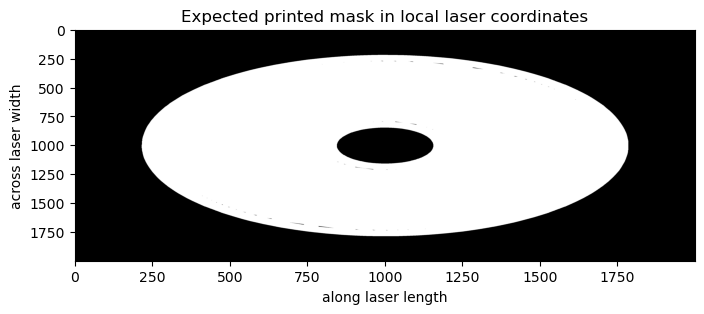

In [114]:
gcode_mask = expected_print_mask_from_segments(
    selected,
    camera_xy=(200, 150),
    px_per_mm=PX_PER_MM,
    theta_deg=THETA_DEG,
    mask_shape=(2000, 2000),
    view_center_offset_mm=VIEW_CENTER_OFFSET_MM,
    line_width_mm=LINE_WIDTH_MM,
)

print('mask shape:', gcode_mask.shape, 'printed pixels:', int(gcode_mask.sum()))
plt.figure(figsize=(8, 3))
plt.imshow(gcode_mask, cmap='gray', origin='upper', aspect='auto')
plt.title('Expected printed mask in local laser coordinates')
plt.xlabel('along laser length')
plt.ylabel('across laser width')
plt.show()


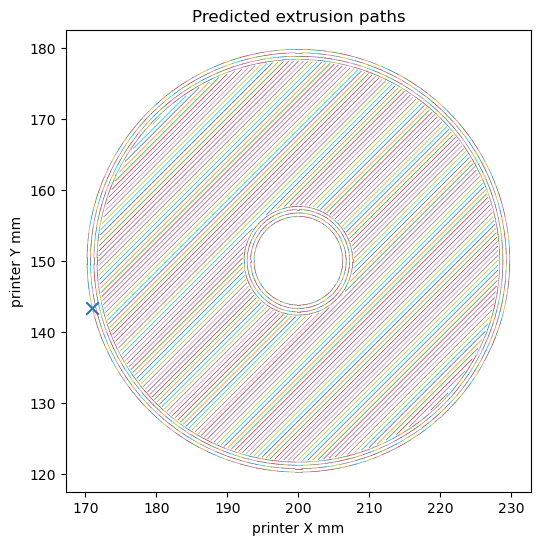

In [ ]:
# Whole G-code path view, useful for checking whether the camera position is plausible.
plt.figure(figsize=(6, 6))
for x0, y0, _z0, x1, y1, _z1, _de, _line in selected:
    plt.plot([x0, x1], [y0, y1], linewidth=0.5)
plt.scatter([0], [0], marker='x', s=80)
plt.axis('equal')
plt.title('Predicted extrusion paths')
plt.xlabel('printer X mm')
plt.ylabel('printer Y mm')
plt.show()


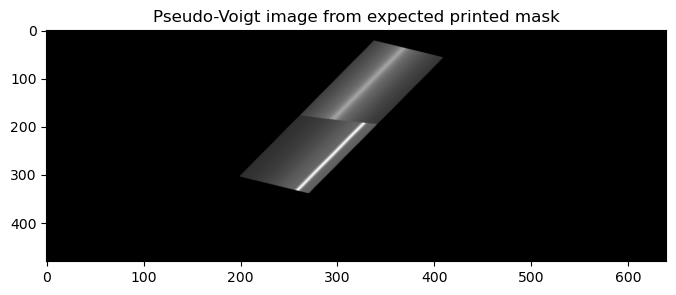

In [102]:
# Use this output directly with the pseudo-Voigt image maker:
from mask_to_laser import make_laser_image
made, dbg = make_laser_image(gcode_mask, EMPTY_TEMPLATE_PATH, FULL_TEMPLATE_PATH, return_debug=True, mask_true='full')
plt.figure(figsize=(8, 3))
plt.imshow(made, cmap='gray', origin='upper', aspect='auto')
plt.title('Pseudo-Voigt image from expected printed mask')
plt.show()



(480, 640) (480, 640)


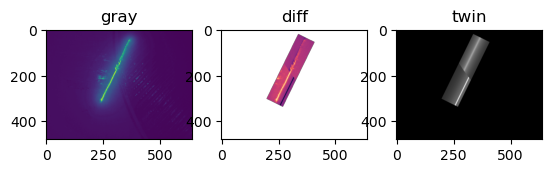

In [95]:
im = cv2.imread(str(FRAME_PATH))
im = cv2.cvtColor(im, cv2.COLOR_BGR2YCR_CB)[:, :, 0]  # Y channel
plt.subplot(1, 3, 1)
plt.imshow(im)
plt.title("gray")
diff = im.astype(float) - made.astype(float)
print(dbg['laser_roi'].shape, diff.shape)
diff[dbg['laser_roi'] == 0] = np.nan  # ignore pixels outside the laser ROI
plt.subplot(1, 3, 2)
plt.title("diff")
plt.imshow(diff, cmap='magma')
plt.subplot(1, 3, 3)
plt.imshow(made, cmap='gray')
plt.title("twin")
plt.show()


## Fast tuning checklist

- For this one-layer G-code, `LAYER_INDEX = 0`.
- For later multi-layer G-code, increase `LAYER_INDEX` as the print moves upward.
- Use `INCLUDE_PREVIOUS_LAYERS = False` for only the current layer. Use `True` for all material already printed up through that layer.
- Layer index does not know print progress within a layer; it renders the whole selected layer unless you add a line-number/time/progress cutoff.
- If the mask is shifted, tune `VIEW_CENTER_OFFSET_MM`.
- If the mask is rotated, tune `THETA_DEG`.
- If the mask has the right shape but wrong scale, tune `PX_PER_MM`.
- If the mask appears mirrored across the width, add a sign flip to the `across` vector in `expected_print_mask_from_segments`.
